# Yelp Reviews - Text Mining

------

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('reviews.csv')

In [3]:
df.columns

Index(['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id',
       'cool', 'useful', 'funny'],
      dtype='object')

In [4]:
df.drop(columns = ['business_id', 'date', 'review_id','type', 'user_id','cool', 'useful', 'funny'], inplace=True)

In [5]:
df

,stars,text
0,5,My wife took me here on my birthday for breakf...
1,5,I have no idea why some people give bad review...
2,4,love the gyro plate. Rice is so good and I als...
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!..."
4,5,General Manager Scott Petello is a good egg!!!...
...,...,...
9995,3,First visit...Had lunch here today - used my G...
9996,4,Should be called house of deliciousness!\n\nI ...
9997,4,I recently visited Olive and Ivy for business ...
9998,2,My nephew just moved to Scottsdale recently so...


In [7]:
df1 = df.copy()

In [11]:
#print(df1.text.head(1))

In [12]:
print(df1.text[0])

My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.

Do yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I've ever had.  I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.

While EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I've ever had.

Anyway, I can't wait to go back!


In [47]:
#positive,happy, (excellent,perfect,pleasure,quickly,better,phenomenal,best,fresh,amazing,tasty,delicious,complete)

In [48]:
print(df1.text[1])

I have no idea why some people give bad reviews about this place. It goes to show you, you can please everyone. They are probably griping about something that their own fault...there are many people like that.

In any case, my friend and I arrived at about 5:50 PM this past Sunday. It was pretty crowded, more than I thought for a Sunday evening and thought we would have to wait forever to get a seat but they said we'll be seated when the girl comes back from seating someone else. We were seated at 5:52 and the waiter came and got our drink orders. Everyone was very pleasant from the host that seated us to the waiter to the server. The prices were very good as well. We placed our orders once we decided what we wanted at 6:02. We shared the baked spaghetti calzone and the small "Here's The Beef" pizza so we can both try them. The calzone was huge and we got the smallest one (personal) and got the small 11" pizza. Both were awesome! My friend liked the pizza better and I liked the calzone

### Import NLP related packages

In [49]:
!pip install wordcloud

In [50]:
!pip install textblob

In [51]:
#import required packages
#basics
#import pandas as pd 
#import numpy as np

#stats
from scipy import sparse
import scipy.stats as ss

#viz
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud ,STOPWORDS     #important tokens, stopwords(especially in English)
from PIL import Image

#nlp
import string
import re               #for regular expressions  H_star, Hstar, --------------> Hotstar
import nltk
from nltk.corpus import stopwords                      #it will show all the stopwords from the English.

#import spacy
from nltk import pos_tag                               #will tell us about POS tagging
from nltk.stem.wordnet import WordNetLemmatizer        #used for lemmatization
from nltk.tokenize import word_tokenize                #used for tokenization
from nltk.stem import PorterStemmer                    #used for Stemming.


#FeatureEngineering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer, TfidfTransformer
from sklearn import model_selection, preprocessing, linear_model, naive_bayes, metrics, svm, decomposition, ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import textblob
#import xgboost

from textblob import TextBlob                          #will give the sentiment score of a text.

In [52]:
df.head()

,stars,text
0,5,My wife took me here on my birthday for breakf...
1,5,I have no idea why some people give bad review...
2,4,love the gyro plate. Rice is so good and I als...
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!..."
4,5,General Manager Scott Petello is a good egg!!!...


### EDA

In [53]:
df.isna().sum()

stars    0
text     0
dtype: int64

In [54]:
len(df)

10000

In [55]:
df.stars.value_counts()

stars
4    3526
5    3337
3    1461
2     927
1     749
Name: count, dtype: int64

In [56]:
print(((3526 + 3337)/10000) * 100,'%')

68.63 %


In [57]:
#68.63% of the people have given a rating of 4 or 5 to the restuarent. Most of the people have given good ratings.

<Axes: xlabel='stars'>

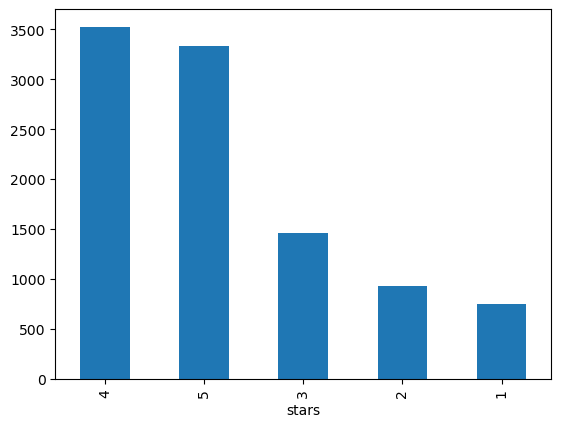

In [58]:
df.stars.value_counts().plot(kind = 'bar')

In [59]:
df.stars.value_counts()

stars
4    3526
5    3337
3    1461
2     927
1     749
Name: count, dtype: int64

In [60]:
df.stars.value_counts(normalize=True)

stars
4    0.3526
5    0.3337
3    0.1461
2    0.0927
1    0.0749
Name: proportion, dtype: float64

### Creation of derived variables

In [61]:
df.head()

,stars,text
0,5,My wife took me here on my birthday for breakf...
1,5,I have no idea why some people give bad review...
2,4,love the gyro plate. Rice is so good and I als...
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!..."
4,5,General Manager Scott Petello is a good egg!!!...


In [62]:
df.text[0]

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\n\nAnyway, I can\'t wait to go back!'

#### Count of words

In [63]:
type(df.text[0])

str

In [64]:
df.text[0]

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\n\nAnyway, I can\'t wait to go back!'

In [65]:
print(df.text[0])

My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.

Do yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I've ever had.  I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.

While EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I've ever had.

Anyway, I can't wait to go back!


In [66]:
len(df.text[0])                                               #it is counting all the characters in the text

889

In [67]:
df.text[0].split()           #when we do not given any separator inside the split(), the default separator is space character.

['My',
 'wife',
 'took',
 'me',
 'here',
 'on',
 'my',
 'birthday',
 'for',
 'breakfast',
 'and',
 'it',
 'was',
 'excellent.',
 'The',
 'weather',
 'was',
 'perfect',
 'which',
 'made',
 'sitting',
 'outside',
 'overlooking',
 'their',
 'grounds',
 'an',
 'absolute',
 'pleasure.',
 'Our',
 'waitress',
 'was',
 'excellent',
 'and',
 'our',
 'food',
 'arrived',
 'quickly',
 'on',
 'the',
 'semi-busy',
 'Saturday',
 'morning.',
 'It',
 'looked',
 'like',
 'the',
 'place',
 'fills',
 'up',
 'pretty',
 'quickly',
 'so',
 'the',
 'earlier',
 'you',
 'get',
 'here',
 'the',
 'better.',
 'Do',
 'yourself',
 'a',
 'favor',
 'and',
 'get',
 'their',
 'Bloody',
 'Mary.',
 'It',
 'was',
 'phenomenal',
 'and',
 'simply',
 'the',
 'best',
 "I've",
 'ever',
 'had.',
 "I'm",
 'pretty',
 'sure',
 'they',
 'only',
 'use',
 'ingredients',
 'from',
 'their',
 'garden',
 'and',
 'blend',
 'them',
 'fresh',
 'when',
 'you',
 'order',
 'it.',
 'It',
 'was',
 'amazing.',
 'While',
 'EVERYTHING',
 'on',
 'the

In [68]:
len(df.text[0].split())  #this is from basic python, we have just splitted the text into words. split()....

155

In [69]:
len(df.text[1].split())

257

In [70]:
df.text[2]

'love the gyro plate. Rice is so good and I also dig their candy selection :)'

In [71]:
len(df.text[2].split())

16

#### Count of unique words

In [2]:
d = "I am living in India and living in India is a different feeling.My friends always tell me to come and live with them in foreign countries.But I love my country and I can never leave my country."

In [4]:
print(d.split())
print(len(d.split()))

['I', 'am', 'living', 'in', 'India', 'and', 'living', 'in', 'India', 'is', 'a', 'different', 'feeling.My', 'friends', 'always', 'tell', 'me', 'to', 'come', 'and', 'live', 'with', 'them', 'in', 'foreign', 'countries.But', 'I', 'love', 'my', 'country', 'and', 'I', 'can', 'never', 'leave', 'my', 'country.']
37


In [5]:
d.split(sep = '.')

['I am living in India and living in India is a different feeling',
 'My friends always tell me to come and live with them in foreign countries',
 'But I love my country and I can never leave my country',
 '']

In [75]:
#len(d.split(sep = '.'))

In [76]:
#len(set(d.split()))

In [77]:
#len(set(df.text[0].split()))

#### Count of sentences

In [79]:
#text.split()  #by default, the separator is a space
#text.split(sep = '\n\n')  #it will on the full stop.

In [80]:
s = df.text[0]

In [81]:
len(s.split(sep='\n\n'))   # this is sentence segmentation....\n  newline character.....escape sequence character...it changes the line.

4

#### Applying functions at dataframe level

In [82]:
df['word_count'] = df['text'].apply(lambda x : len(x.split()))

In [ ]:
df

In [83]:
df['unique_word_count'] = df['text'].apply(lambda x : len(set(x.split())))

In [ ]:
df

In [84]:
df['sentences'] = df['text'].apply(lambda x : len(set(x.split(sep='.'))))

In [ ]:
df

In [85]:
df.text[0].split('.')

['My wife took me here on my birthday for breakfast and it was excellent',
 '  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure',
 '  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning',
 '  It looked like the place fills up pretty quickly so the earlier you get here the better',
 '\n\nDo yourself a favor and get their Bloody Mary',
 "  It was phenomenal and simply the best I've ever had",
 "  I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it",
 '  It was amazing',
 '\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious',
 '  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete',
 '  It was the best "toast" I\'ve ever had',
 "\n\nAnyway, I can't wait to go back!"]

In [86]:
s = df.text[0]

In [87]:
s

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\n\nAnyway, I can\'t wait to go back!'

In [ ]:
#SYNTAX of LC: [final output for i in iterable if priority_condition]

In [88]:
list([x for x in s.split() if x.isdigit()])

['2']

In [89]:
df['no_of_numerics'] = df.text.apply(lambda s: len(list([x for x in s.split() if x.isdigit()])))

In [90]:
df

,stars,text,word_count,unique_word_count,sentences,no_of_numerics
0,5,My wife took me here on my birthday for breakf...,155,110,12,1
1,5,I have no idea why some people give bad review...,257,159,17,0
2,4,love the gyro plate. Rice is so good and I als...,16,16,2,0
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",76,61,5,0
4,5,General Manager Scott Petello is a good egg!!!...,86,72,6,0
...,...,...,...,...,...,...
9995,3,First visit...Had lunch here today - used my G...,120,90,13,0
9996,4,Should be called house of deliciousness!\n\nI ...,161,120,9,0
9997,4,I recently visited Olive and Ivy for business ...,262,168,12,2
9998,2,My nephew just moved to Scottsdale recently so...,147,119,18,1


In [ ]:
#df = df.drop(columns = 'text_numbers')

In [ ]:
# Below is the examples of all the possible 'x' variables:

In [92]:
df['text'] = df['text'].astype(str)
df['count_sent']=df["text"].apply(lambda x: len(re.findall("\n",str(x)))+1)

#Word count in each comment:
df['count_word']=df["text"].apply(lambda x: len(str(x).split()))

#Unique word count
df['count_unique_word']=df["text"].apply(lambda x: len(set(str(x).split())))

#Letter count
df['count_letters']=df["text"].apply(lambda x: len(str(x)))

#Word density

df['word_density'] = df['count_letters'] / (df['count_word']+1)

#punctuation count
df["count_punctuations"] =df["text"].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

#upper case words count
df["count_words_upper"] = df["text"].apply(lambda x: len([w for w in str(x).split() if w.isupper()]))

#upper case words count
df["count_words_lower"] = df["text"].apply(lambda x: len([w for w in str(x).split() if w.islower()]))

#title case words count
df["count_words_title"] = df["text"].apply(lambda x: len([w for w in str(x).split() if w.istitle()]))

#Number of stopwords
df["count_stopwords"] = df["text"].apply(lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords]))

#Average length of the words
df["mean_word_len"] = df["text"].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

#Number of numeric
df['numeric'] = df['text'].apply(lambda x :len([x for x in x.split() if x.isdigit()]))

#Number of alphanumeric
df['alphanumeric'] = df['text'].apply(lambda x :len([x for x in x.split() if x.isalnum()]))

#Number of alphabetics
df['alphabetetics'] = df['text'].apply(lambda x :len([x for x in x.split() if x.isalpha()]))

#Number of alphabetics
df['Spaces'] = df['text'].apply(lambda x :len([x for x in x.split() if x.isspace()]))

#Number of Words ends with
df['words_ends_with_et'] = df['text'].apply(lambda x :len([x for x in x.lower().split() if x.endswith('et')]))

#Number of Words ends with
df['words_start_with_no'] = df['text'].apply(lambda x :len([x for x in x.lower().split() if x.startswith('no')]))

# Count the occurences of all words
df['wordcounts'] = df['text'].apply(lambda x :dict([ [t, x.split().count(t)] for t in set(x.split()) ]))

pos_family = {
    'noun' : ['NN','NNS','NNP','NNPS'],
    'pron' : ['PRP','PRP$','WP','WP$'],
    'verb' : ['VB','VBD','VBG','VBN','VBP','VBZ'],
    'adj' :  ['JJ','JJR','JJS'],
    'adv' : ['RB','RBR','RBS','WRB']
}

# function to check and get the part of speech tag count of a words in a given sentence
def check_pos_tag(x, flag):
    cnt = 0
    try:
        wiki = textblob.TextBlob(x)
        for tup in wiki.tags:
            ppo = list(tup)[1]
            if ppo in pos_family[flag]:
                cnt += 1
    except:
        pass
    return cnt

df['noun_count'] = df['text'].apply(lambda x: check_pos_tag(x, 'noun'))
df['verb_count'] = df['text'].apply(lambda x: check_pos_tag(x, 'verb'))
df['adj_count']  = df['text'].apply(lambda x: check_pos_tag(x, 'adj'))
df['adv_count']  = df['text'].apply(lambda x: check_pos_tag(x, 'adv'))
df['pron_count'] = df['text'].apply(lambda x: check_pos_tag(x, 'pron')) 

NameError: name 'eng_stopwords' is not defined

In [ ]:
df1

In [ ]:
df = df1.copy()

In [ ]:
df

### Sentiment Score

In [ ]:
#NLTK: Natural Language Toolkit

In [93]:
sample1 = 'The food is brilliant. The ambience was excellent and the service is awesome.'
sample2 = 'The service was pathetic and disgusting.'
sample3 = 'the ambience of the restuarent was good but the price was too high so I might choose some different option next time.'

In [ ]:
#food, brilliant, ambience, excellent, service, awesome

In [ ]:
#sample1 --> Positive
#sample2 --> Negative

In [94]:
TextBlob(sample1).sentiment.polarity

0.967

In [95]:
TextBlob(sample2).sentiment.polarity

-1.0

In [96]:
TextBlob(sample3).sentiment.polarity

0.215

In [97]:
df.text[0]                  #TextBlob(df.text[0]).sentiment.polarity

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\n\nAnyway, I can\'t wait to go back!'

In [98]:
round(TextBlob(df.text[0]).sentiment.polarity,3)

0.402

In [52]:
df.text[1]

'I have no idea why some people give bad reviews about this place. It goes to show you, you can please everyone. They are probably griping about something that their own fault...there are many people like that.\n\nIn any case, my friend and I arrived at about 5:50 PM this past Sunday. It was pretty crowded, more than I thought for a Sunday evening and thought we would have to wait forever to get a seat but they said we\'ll be seated when the girl comes back from seating someone else. We were seated at 5:52 and the waiter came and got our drink orders. Everyone was very pleasant from the host that seated us to the waiter to the server. The prices were very good as well. We placed our orders once we decided what we wanted at 6:02. We shared the baked spaghetti calzone and the small "Here\'s The Beef" pizza so we can both try them. The calzone was huge and we got the smallest one (personal) and got the small 11" pizza. Both were awesome! My friend liked the pizza better and I liked the ca

In [100]:
round(TextBlob(df.text[1]).sentiment.polarity,3)

0.23

In [104]:
df['sentiment_score'] = df.text.apply(lambda x: TextBlob(x).sentiment.polarity)

In [105]:
df

,stars,text,word_count,unique_word_count,sentences,no_of_numerics,count_sent,count_word,count_unique_word,count_letters,word_density,count_punctuations,count_words_upper,count_words_lower,count_words_title,sentiment_score
0,5,My wife took me here on my birthday for breakf...,155,110,12,1,7,155,110,889,5.698718,21,3,134,16,0.402469
1,5,I have no idea why some people give bad review...,257,159,17,0,5,257,159,1345,5.213178,36,6,225,25,0.229773
2,4,love the gyro plate. Rice is so good and I als...,16,16,2,0,1,16,16,76,4.470588,3,1,13,2,0.566667
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",76,61,5,0,5,76,61,419,5.441558,18,2,61,13,0.608646
4,5,General Manager Scott Petello is a good egg!!!...,86,72,6,0,3,86,72,469,5.390805,38,2,70,12,0.468125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,First visit...Had lunch here today - used my G...,120,90,13,0,13,120,90,668,5.520661,27,1,93,20,0.217708
9996,4,Should be called house of deliciousness!\n\nI ...,161,120,9,0,8,161,120,881,5.438272,14,4,148,13,0.375541
9997,4,I recently visited Olive and Ivy for business ...,262,168,12,2,8,262,168,1425,5.418251,31,7,231,28,0.264633
9998,2,My nephew just moved to Scottsdale recently so...,147,119,18,1,1,147,119,880,5.945946,64,5,128,9,-0.082366


In [106]:
df['new_sentiment'] = np.where(df.sentiment_score > 0.25, 'Positive', 
                               np.where(df.sentiment_score <-0.05, 'Negative', 'Neutral'))

In [107]:
df

,stars,text,word_count,unique_word_count,sentences,no_of_numerics,count_sent,count_word,count_unique_word,count_letters,word_density,count_punctuations,count_words_upper,count_words_lower,count_words_title,sentiment_score,new_sentiment
0,5,My wife took me here on my birthday for breakf...,155,110,12,1,7,155,110,889,5.698718,21,3,134,16,0.402469,Positive
1,5,I have no idea why some people give bad review...,257,159,17,0,5,257,159,1345,5.213178,36,6,225,25,0.229773,Neutral
2,4,love the gyro plate. Rice is so good and I als...,16,16,2,0,1,16,16,76,4.470588,3,1,13,2,0.566667,Positive
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",76,61,5,0,5,76,61,419,5.441558,18,2,61,13,0.608646,Positive
4,5,General Manager Scott Petello is a good egg!!!...,86,72,6,0,3,86,72,469,5.390805,38,2,70,12,0.468125,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,3,First visit...Had lunch here today - used my G...,120,90,13,0,13,120,90,668,5.520661,27,1,93,20,0.217708,Neutral
9996,4,Should be called house of deliciousness!\n\nI ...,161,120,9,0,8,161,120,881,5.438272,14,4,148,13,0.375541,Positive
9997,4,I recently visited Olive and Ivy for business ...,262,168,12,2,8,262,168,1425,5.418251,31,7,231,28,0.264633,Positive
9998,2,My nephew just moved to Scottsdale recently so...,147,119,18,1,1,147,119,880,5.945946,64,5,128,9,-0.082366,Negative


In [ ]:
#Crosstable or Confusion Matrix or Contingency table   : relationship between two random categorical variables in the data.

In [110]:
pd.crosstab(df.stars,df.new_sentiment, margins = True)

new_sentiment,Negative,Neutral,Positive,All
stars,,,,
1,250,463,36,749
2,126,673,128,927
3,49,978,434,1461
4,50,1617,1859,3526
5,42,1100,2195,3337
All,517,4831,4652,10000


In [109]:
pd.crosstab(df.stars,df.new_sentiment, normalize = True)

new_sentiment,Negative,Neutral,Positive
stars,,,
1,0.0250,0.0463,0.0036
2,0.0126,0.0673,0.0128
3,0.0049,0.0978,0.0434
4,0.0050,0.1617,0.1859
5,0.0042,0.1100,0.2195


### Clean the data

In [66]:
df = df1.copy()

In [67]:
df

,stars,text
0,5,My wife took me here on my birthday for breakf...
1,5,I have no idea why some people give bad review...
2,4,love the gyro plate. Rice is so good and I als...
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!..."
4,5,General Manager Scott Petello is a good egg!!!...
...,...,...
9995,3,First visit...Had lunch here today - used my G...
9996,4,Should be called house of deliciousness!\n\nI ...
9997,4,I recently visited Olive and Ivy for business ...
9998,2,My nephew just moved to Scottsdale recently so...


In [68]:
df.text[0]

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\n\nAnyway, I can\'t wait to go back!'

In [69]:
df.text[0].lower()

'my wife took me here on my birthday for breakfast and it was excellent.  the weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  our waitress was excellent and our food arrived quickly on the semi-busy saturday morning.  it looked like the place fills up pretty quickly so the earlier you get here the better.\n\ndo yourself a favor and get their bloody mary.  it was phenomenal and simply the best i\'ve ever had.  i\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  it was amazing.\n\nwhile everything on the menu looks excellent, i had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  it came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  it was the best "toast" i\'ve ever had.\n\nanyway, i can\'t wait to go back!'

In [74]:
re.sub(r"[\n.!-\\]", "",df.text[0].lower())               #Regex : Regular Expressions

'my wife took me here on my birthday for breakfast and it was excellent  the weather was perfect which made sitting outside overlooking their grounds an absolute pleasure  our waitress was excellent and our food arrived quickly on the semibusy saturday morning  it looked like the place fills up pretty quickly so the earlier you get here the betterdo yourself a favor and get their bloody mary  it was phenomenal and simply the best ive ever had  im pretty sure they only use ingredients from their garden and blend them fresh when you order it  it was amazingwhile everything on the menu looks excellent i had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious  it came with  pieces of their griddled bread with was amazing and it absolutely made the meal complete  it was the best toast ive ever hadanyway i cant wait to go back'

In [ ]:
df['text_without_marks'] = df.text.apply(lambda x: re.sub(r"[\d\n.:;!-\\]","",x.lower()))

## Working on Stopwords

In [114]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Siddhant\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [115]:
from nltk.corpus import stopwords

In [116]:
s1 = list(stopwords.words('english'))

In [124]:
#s2 = list(stopwords.words('French'))

In [78]:
s1

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [84]:
df.text[0].split()

['My',
 'wife',
 'took',
 'me',
 'here',
 'on',
 'my',
 'birthday',
 'for',
 'breakfast',
 'and',
 'it',
 'was',
 'excellent.',
 'The',
 'weather',
 'was',
 'perfect',
 'which',
 'made',
 'sitting',
 'outside',
 'overlooking',
 'their',
 'grounds',
 'an',
 'absolute',
 'pleasure.',
 'Our',
 'waitress',
 'was',
 'excellent',
 'and',
 'our',
 'food',
 'arrived',
 'quickly',
 'on',
 'the',
 'semi-busy',
 'Saturday',
 'morning.',
 'It',
 'looked',
 'like',
 'the',
 'place',
 'fills',
 'up',
 'pretty',
 'quickly',
 'so',
 'the',
 'earlier',
 'you',
 'get',
 'here',
 'the',
 'better.',
 'Do',
 'yourself',
 'a',
 'favor',
 'and',
 'get',
 'their',
 'Bloody',
 'Mary.',
 'It',
 'was',
 'phenomenal',
 'and',
 'simply',
 'the',
 'best',
 "I've",
 'ever',
 'had.',
 "I'm",
 'pretty',
 'sure',
 'they',
 'only',
 'use',
 'ingredients',
 'from',
 'their',
 'garden',
 'and',
 'blend',
 'them',
 'fresh',
 'when',
 'you',
 'order',
 'it.',
 'It',
 'was',
 'amazing.',
 'While',
 'EVERYTHING',
 'on',
 'the

In [125]:
k = "I am having a good Saturday."

In [126]:
k.lower()

'i am having a good saturday.'

In [81]:
list([x for x in df.text[0].lower().split() if x not in s1])

['wife',
 'took',
 'birthday',
 'breakfast',
 'excellent.',
 'weather',
 'perfect',
 'made',
 'sitting',
 'outside',
 'overlooking',
 'grounds',
 'absolute',
 'pleasure.',
 'waitress',
 'excellent',
 'food',
 'arrived',
 'quickly',
 'semi-busy',
 'saturday',
 'morning.',
 'looked',
 'like',
 'place',
 'fills',
 'pretty',
 'quickly',
 'earlier',
 'get',
 'better.',
 'favor',
 'get',
 'bloody',
 'mary.',
 'phenomenal',
 'simply',
 'best',
 "i've",
 'ever',
 'had.',
 "i'm",
 'pretty',
 'sure',
 'use',
 'ingredients',
 'garden',
 'blend',
 'fresh',
 'order',
 'it.',
 'amazing.',
 'everything',
 'menu',
 'looks',
 'excellent,',
 'white',
 'truffle',
 'scrambled',
 'eggs',
 'vegetable',
 'skillet',
 'tasty',
 'delicious.',
 'came',
 '2',
 'pieces',
 'griddled',
 'bread',
 'amazing',
 'absolutely',
 'made',
 'meal',
 'complete.',
 'best',
 '"toast"',
 "i've",
 'ever',
 'had.',
 'anyway,',
 "can't",
 'wait',
 'go',
 'back!']

In [85]:
TextBlob(df.text[0]).sentiment.polarity

0.40246913580246907

In [86]:
' '.join(list([x for x in df.text[0].lower().split() if x not in s1]))

'wife took birthday breakfast excellent. weather perfect made sitting outside overlooking grounds absolute pleasure. waitress excellent food arrived quickly semi-busy saturday morning. looked like place fills pretty quickly earlier get better. favor get bloody mary. phenomenal simply best i\'ve ever had. i\'m pretty sure use ingredients garden blend fresh order it. amazing. everything menu looks excellent, white truffle scrambled eggs vegetable skillet tasty delicious. came 2 pieces griddled bread amazing absolutely made meal complete. best "toast" i\'ve ever had. anyway, can\'t wait go back!'

In [87]:
TextBlob(' '.join(list([x for x in df.text[0].lower().split() if x not in s1]))).sentiment.polarity

0.43888888888888883

In [88]:
len(list([x for x in df.text[0].lower().split() if x not in s1]))

84

In [89]:
len(df.text[0].split())

155

In [90]:
df['cleaned_review'] = df.text.apply(lambda s: ' '.join(list([x for x in s.lower().split() if x not in s1])))

In [91]:
df

,stars,text,cleaned_review
0,5,My wife took me here on my birthday for breakf...,wife took birthday breakfast excellent. weathe...
1,5,I have no idea why some people give bad review...,idea people give bad reviews place. goes show ...
2,4,love the gyro plate. Rice is so good and I als...,love gyro plate. rice good also dig candy sele...
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...","rosie, dakota, love chaparral dog park!!! conv..."
4,5,General Manager Scott Petello is a good egg!!!...,general manager scott petello good egg!!! go d...
...,...,...,...
9995,3,First visit...Had lunch here today - used my G...,first visit...had lunch today - used groupon. ...
9996,4,Should be called house of deliciousness!\n\nI ...,"called house deliciousness! could go item, ite..."
9997,4,I recently visited Olive and Ivy for business ...,"recently visited olive ivy business last week,..."
9998,2,My nephew just moved to Scottsdale recently so...,nephew moved scottsdale recently bunch friends...


In [93]:
df['sentiment_score_cleaned'] = df.cleaned_review.apply(lambda x : TextBlob(x).sentiment.polarity)

In [94]:
df['sentiment_score_original'] = df.text.apply(lambda x: TextBlob(x).sentiment.polarity)

In [95]:
df

,stars,text,cleaned_review,sentiment_score_cleaned,sentiment_score_original
0,5,My wife took me here on my birthday for breakf...,wife took birthday breakfast excellent. weathe...,0.438889,0.402469
1,5,I have no idea why some people give bad review...,idea people give bad reviews place. goes show ...,0.176250,0.229773
2,4,love the gyro plate. Rice is so good and I als...,love gyro plate. rice good also dig candy sele...,0.566667,0.566667
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...","rosie, dakota, love chaparral dog park!!! conv...",0.710807,0.608646
4,5,General Manager Scott Petello is a good egg!!!...,general manager scott petello good egg!!! go d...,0.468125,0.468125
...,...,...,...,...,...
9995,3,First visit...Had lunch here today - used my G...,first visit...had lunch today - used groupon. ...,0.217708,0.217708
9996,4,Should be called house of deliciousness!\n\nI ...,"called house deliciousness! could go item, ite...",0.375541,0.375541
9997,4,I recently visited Olive and Ivy for business ...,"recently visited olive ivy business last week,...",0.278216,0.264633
9998,2,My nephew just moved to Scottsdale recently so...,nephew moved scottsdale recently bunch friends...,-0.082366,-0.082366


In [96]:
df.corr()

,stars,sentiment_score_cleaned,sentiment_score_original
stars,1.000000,0.474448,0.489989
sentiment_score_cleaned,0.474448,1.000000,0.960492
sentiment_score_original,0.489989,0.960492,1.000000


In [101]:
df['original_length'] = df.text.apply(lambda x:len(x))

In [102]:
df['cleaned_review_length'] = df.cleaned_review.apply(lambda x:len(x))

In [103]:
df

,stars,text,cleaned_review,sentiment_score_cleaned,sentiment_score_original,original_length,cleaned_review_length
0,5,My wife took me here on my birthday for breakf...,wife took birthday breakfast excellent. weathe...,0.438889,0.402469,889,594
1,5,I have no idea why some people give bad review...,idea people give bad reviews place. goes show ...,0.176250,0.229773,1345,803
2,4,love the gyro plate. Rice is so good and I als...,love gyro plate. rice good also dig candy sele...,0.566667,0.566667,76,54
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...","rosie, dakota, love chaparral dog park!!! conv...",0.710807,0.608646,419,296
4,5,General Manager Scott Petello is a good egg!!!...,general manager scott petello good egg!!! go d...,0.468125,0.468125,469,295
...,...,...,...,...,...,...,...
9995,3,First visit...Had lunch here today - used my G...,first visit...had lunch today - used groupon. ...,0.217708,0.217708,668,462
9996,4,Should be called house of deliciousness!\n\nI ...,"called house deliciousness! could go item, ite...",0.375541,0.375541,881,605
9997,4,I recently visited Olive and Ivy for business ...,"recently visited olive ivy business last week,...",0.278216,0.264633,1425,947
9998,2,My nephew just moved to Scottsdale recently so...,nephew moved scottsdale recently bunch friends...,-0.082366,-0.082366,880,627


In [105]:
df.original_length.sum()

7107387

In [106]:
df.cleaned_review_length.sum()

4712331

In [107]:
df.text.apply(lambda x: )

0       My wife took me here on my birthday for breakf...
1       I have no idea why some people give bad review...
2       love the gyro plate. Rice is so good and I als...
3       Rosie, Dakota, and I LOVE Chaparral Dog Park!!...
4       General Manager Scott Petello is a good egg!!!...
                              ...                        
9995    First visit...Had lunch here today - used my G...
9996    Should be called house of deliciousness!\n\nI ...
9997    I recently visited Olive and Ivy for business ...
9998    My nephew just moved to Scottsdale recently so...
9999    4-5 locations.. all 4.5 star average.. I think...
Name: text, Length: 10000, dtype: object

In [114]:
def length_of_string(s):
    return len(s)

In [115]:
length_of_string('My name is Navneet')

18

In [116]:
df['length_udf'] = df.text.apply(length_of_string)

In [117]:
df

,stars,text,cleaned_review,sentiment_score_cleaned,sentiment_score_original,original_length,cleaned_review_length,length_udf
0,5,My wife took me here on my birthday for breakf...,wife took birthday breakfast excellent. weathe...,0.438889,0.402469,889,594,889
1,5,I have no idea why some people give bad review...,idea people give bad reviews place. goes show ...,0.176250,0.229773,1345,803,1345
2,4,love the gyro plate. Rice is so good and I als...,love gyro plate. rice good also dig candy sele...,0.566667,0.566667,76,54,76
3,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...","rosie, dakota, love chaparral dog park!!! conv...",0.710807,0.608646,419,296,419
4,5,General Manager Scott Petello is a good egg!!!...,general manager scott petello good egg!!! go d...,0.468125,0.468125,469,295,469
...,...,...,...,...,...,...,...,...
9995,3,First visit...Had lunch here today - used my G...,first visit...had lunch today - used groupon. ...,0.217708,0.217708,668,462,668
9996,4,Should be called house of deliciousness!\n\nI ...,"called house deliciousness! could go item, ite...",0.375541,0.375541,881,605,881
9997,4,I recently visited Olive and Ivy for business ...,"recently visited olive ivy business last week,...",0.278216,0.264633,1425,947,1425
9998,2,My nephew just moved to Scottsdale recently so...,nephew moved scottsdale recently bunch friends...,-0.082366,-0.082366,880,627,880


In [ ]:
import string
def pre_process(text):
    #text = text.str.replace('/','')                           #Replacing the / with none
    #text = text.apply(lambda x: re.sub("  "," ", x))          #Replacing double space with single space
    #text = re.sub(r"[-()\"#/@;:{}`+=~|.!?,']", "", text)      #Replacing special character with none
    #text = re.sub(r'[0-9]+', '', text)                        #Replacing numbers with none
    #text = text.apply(lambda x: " ".join(x.translate(str.maketrans('', '', string.punctuation)) for x in x.split() if x.isalpha()))
    #text = text.apply(lambda x: " ".join(x for x in x.split() if x not in stop)) #Removing stop words
    #text = text.apply(lambda x: str(TextBlob(x).correct()))                      #Correct spelling corrections
    #text = text.apply(lambda x: " ".join(PorterStemmer().stem(word) for word in x.split())) #Stemming using porter stemmer
    #text = text.apply(lambda x: " ".join(stemmer_func(word) for word in x.split()))        #Stemming
    #text = text.apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))   #lemmatization
    #text = text.apply(lambda x: " ".join(word for word, pos in pos_tag(x.split()) if pos not in ['NN','NNS','NNP','NNPS'])) #Removing nouns etc
    return(text)

In [124]:
s = 'Variouus'

In [125]:
TextBlob(s).correct()

TextBlob("Various")

In [ ]:
#new_data['stars'] = original_data['stars']

In [128]:
positive_ratings = df[df.stars == 5].text

In [129]:
positive_ratings

0       My wife took me here on my birthday for breakf...
1       I have no idea why some people give bad review...
3       Rosie, Dakota, and I LOVE Chaparral Dog Park!!...
4       General Manager Scott Petello is a good egg!!!...
6       Drop what you're doing and drive here. After I...
                              ...                        
9990    Yes I do rock the hipster joints.  I dig this ...
9991    Only 4 stars? \n\n(A few notes: The folks that...
9992    I'm not normally one to jump at reviewing a ch...
9994    Let's see...what is there NOT to like about Su...
9999    4-5 locations.. all 4.5 star average.. I think...
Name: text, Length: 3337, dtype: object

In [127]:
from wordcloud import WordCloud ,STOPWORDS

In [134]:
' '.join(positive_ratings.tolist())

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\n\nAnyway, I can\'t wait to go back! I have no idea why some people give bad reviews about this place. It goes to show you, you can plea

In [139]:
STOPWORDS

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

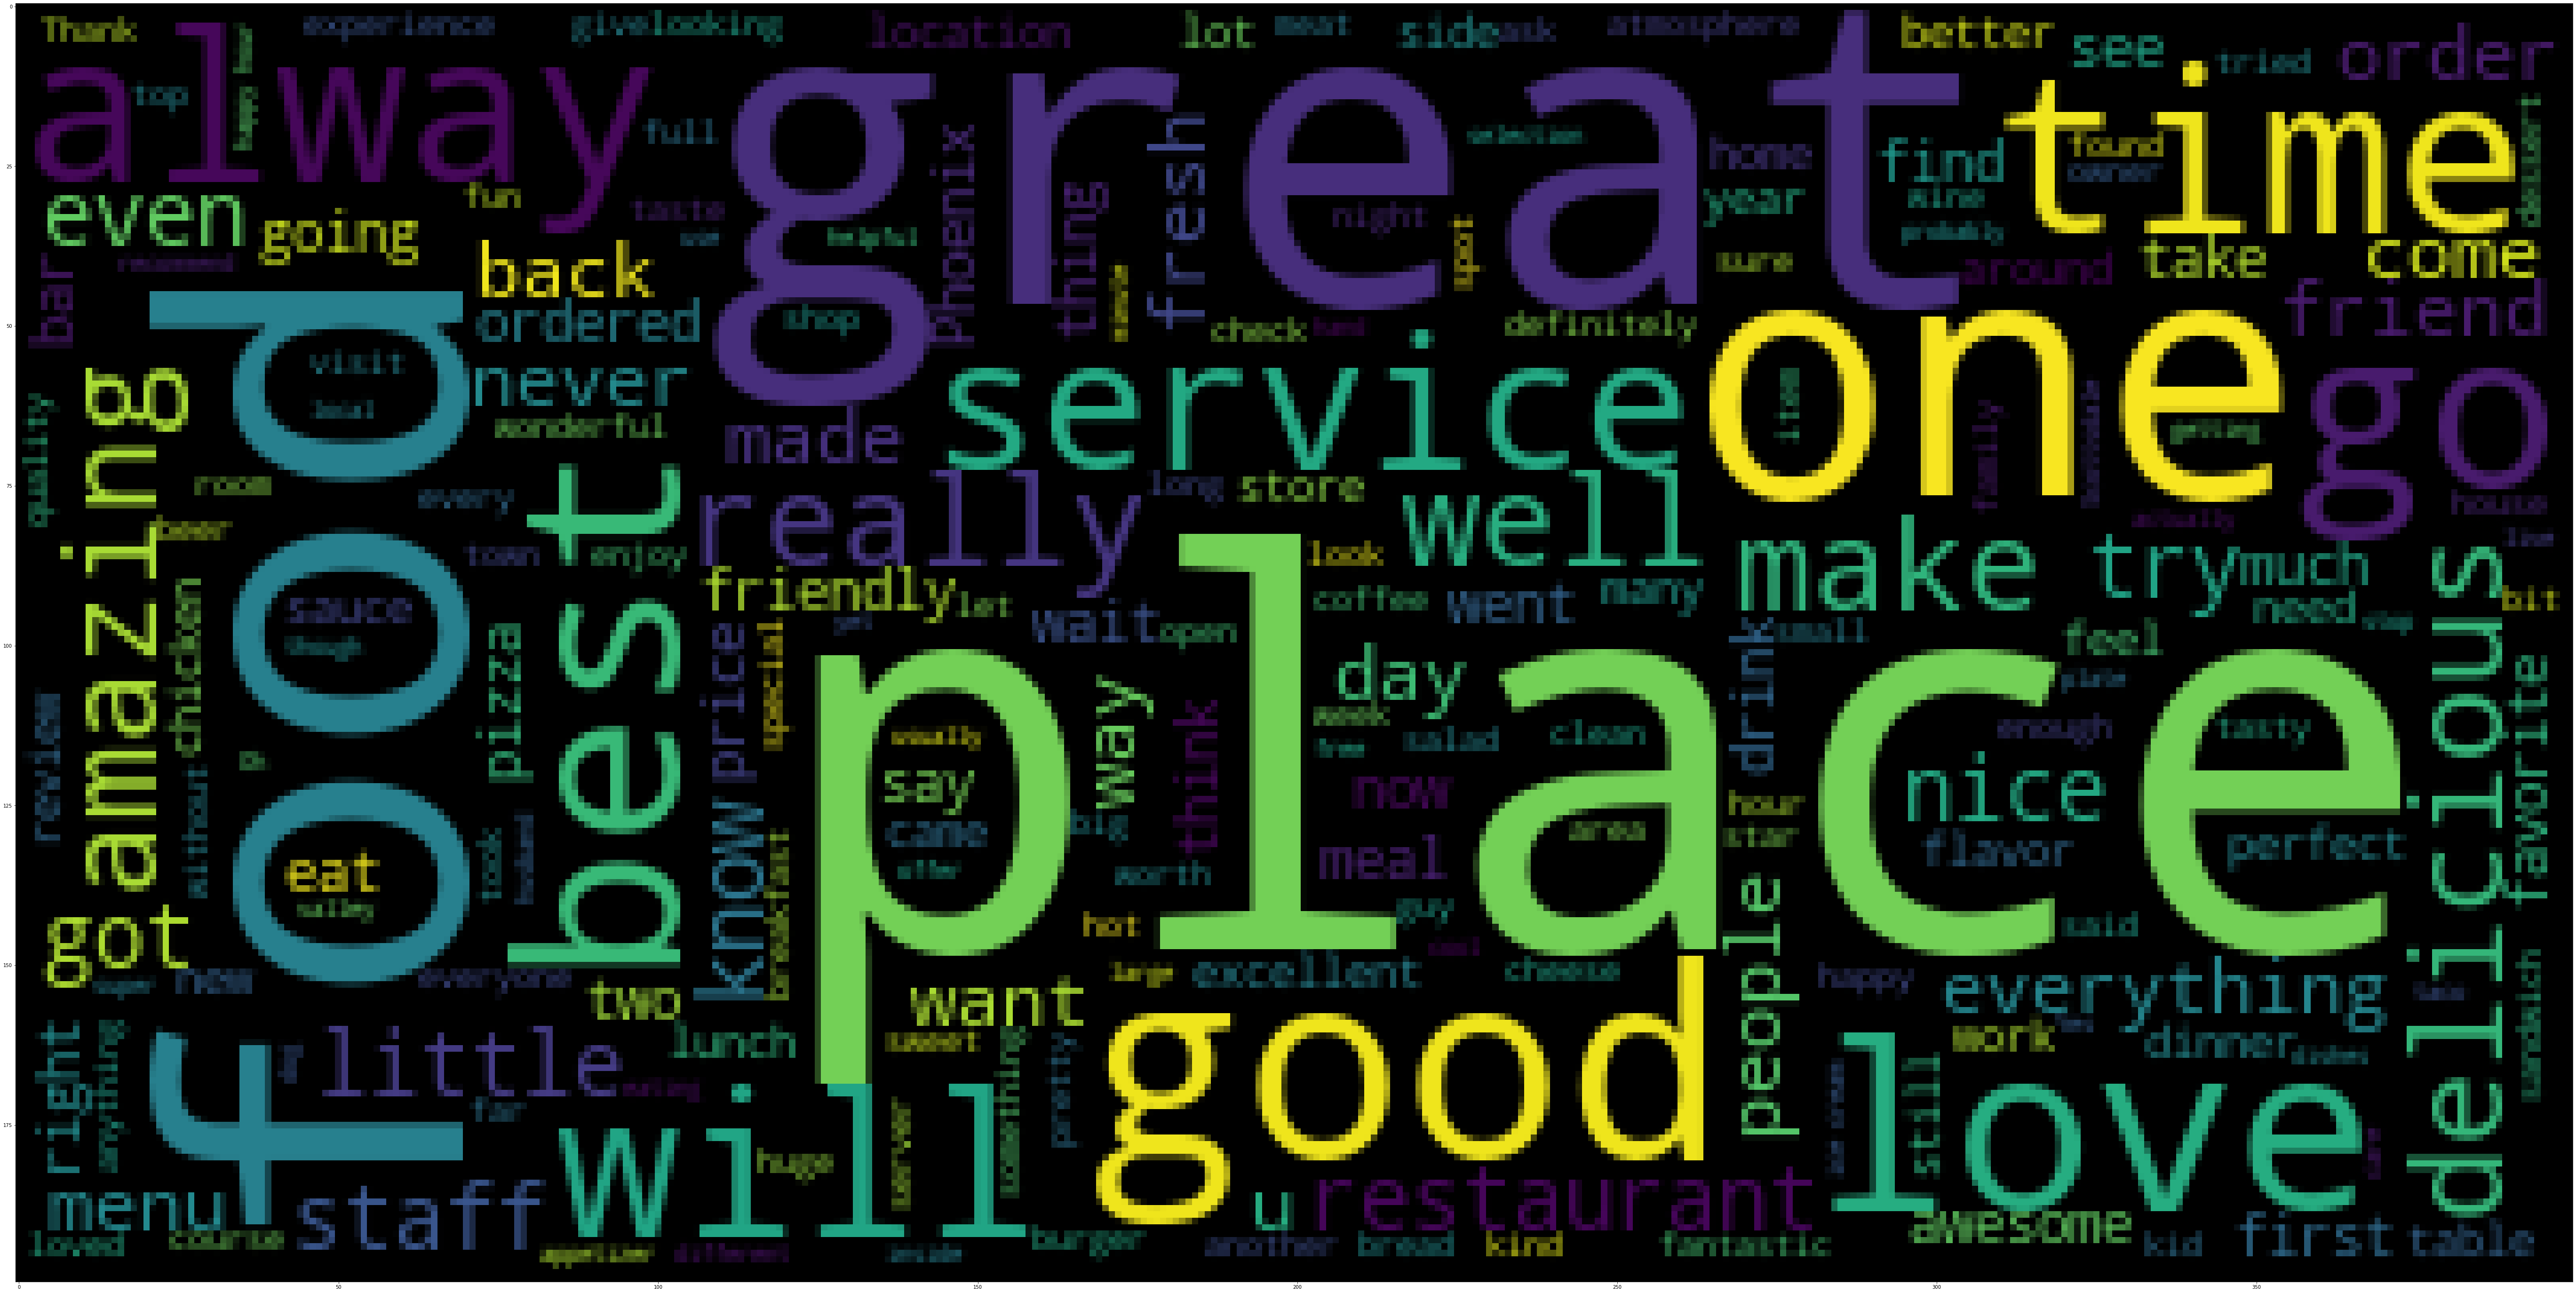

In [142]:
wc = WordCloud().generate(' '.join(positive_ratings.tolist()))

%matplotlib inline
fig = plt.figure(figsize=(200,50))
plt.imshow(wc)

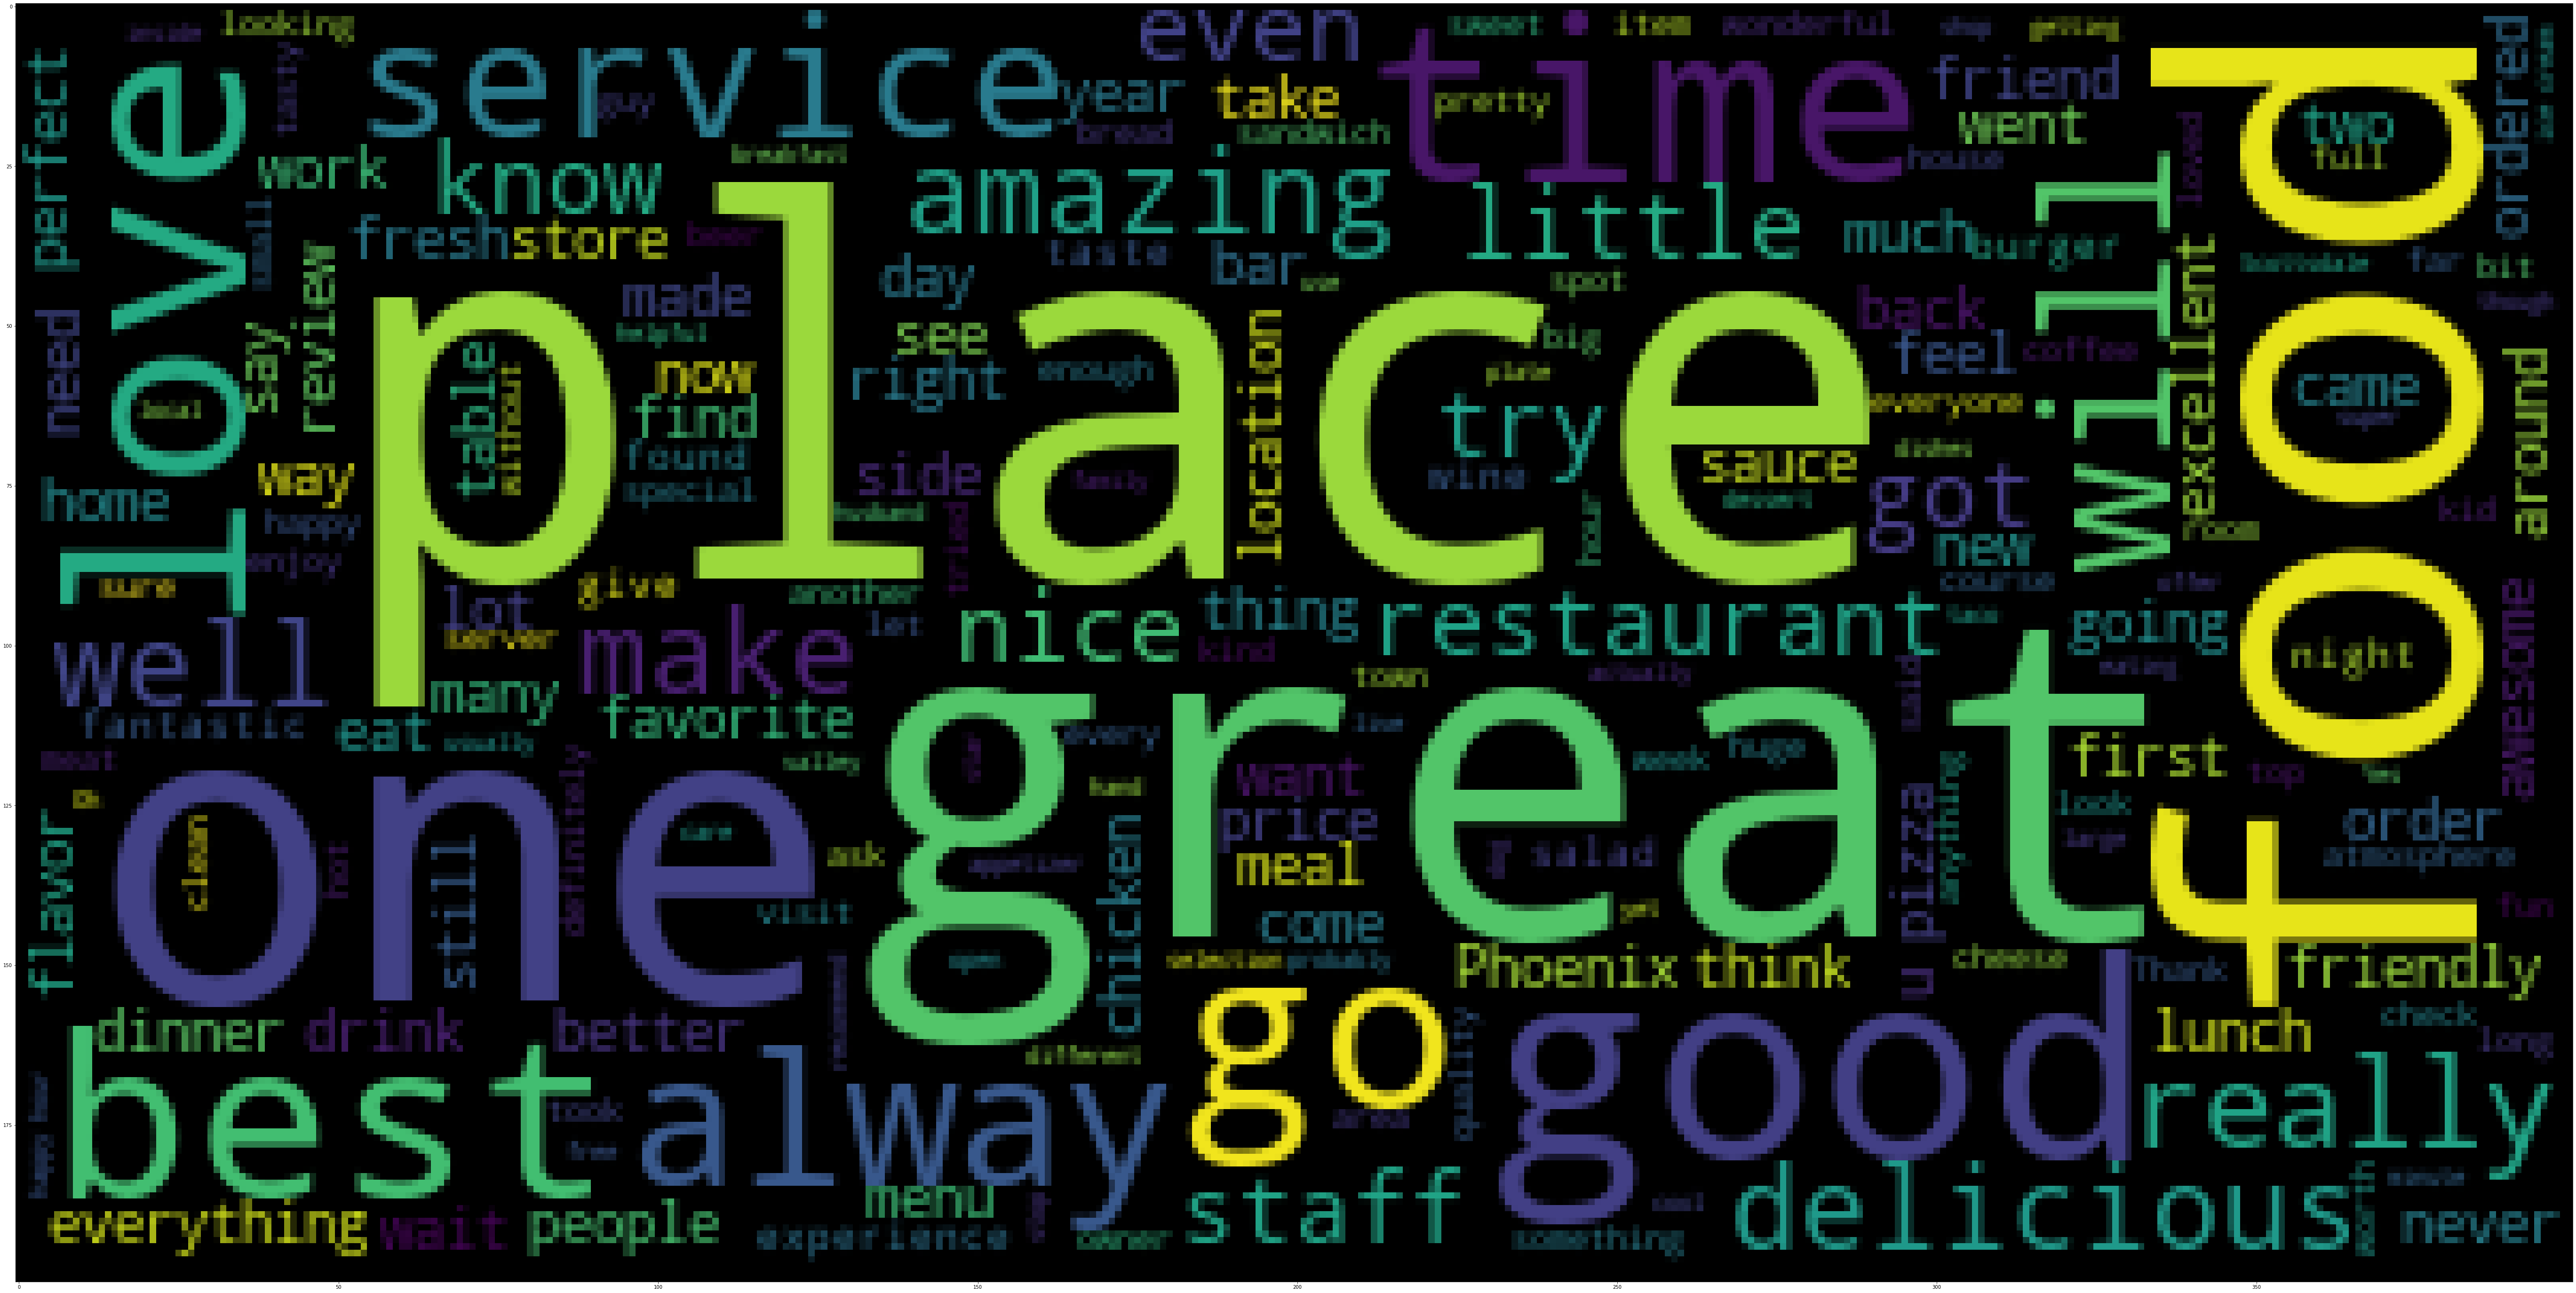

In [143]:
wc = WordCloud(stopwords = STOPWORDS).generate(' '.join(positive_ratings.tolist()))

%matplotlib inline
fig = plt.figure(figsize=(200,50))
plt.imshow(wc)

In [149]:
stop1 = list(STOPWORDS) + ['place','great','good']
stop1

['in',
 'his',
 "you're",
 'can',
 "shan't",
 'herself',
 'how',
 "he'd",
 'him',
 'most',
 'no',
 'does',
 "she'd",
 "who's",
 "we're",
 'under',
 "weren't",
 'our',
 'yourself',
 'theirs',
 'being',
 'should',
 'while',
 'with',
 'after',
 'you',
 'above',
 'like',
 "i'll",
 'http',
 'my',
 'more',
 'that',
 'otherwise',
 'their',
 "won't",
 'why',
 'once',
 'which',
 'did',
 'where',
 "she'll",
 "they're",
 'doing',
 'however',
 "it's",
 'it',
 "isn't",
 'itself',
 'before',
 'very',
 'could',
 'had',
 'for',
 'a',
 'therefore',
 'nor',
 'do',
 'up',
 'from',
 'out',
 'hers',
 'own',
 'at',
 'against',
 'because',
 'i',
 'not',
 "why's",
 'k',
 'were',
 'over',
 'these',
 'hence',
 'until',
 'myself',
 'and',
 'r',
 'www',
 'been',
 "let's",
 "can't",
 'if',
 'its',
 'whom',
 'would',
 'those',
 'just',
 'such',
 'yours',
 'there',
 'by',
 'this',
 "mustn't",
 'having',
 "they'll",
 'com',
 "didn't",
 "she's",
 "shouldn't",
 "they've",
 "what's",
 'the',
 "you'd",
 "you'll",
 'they'

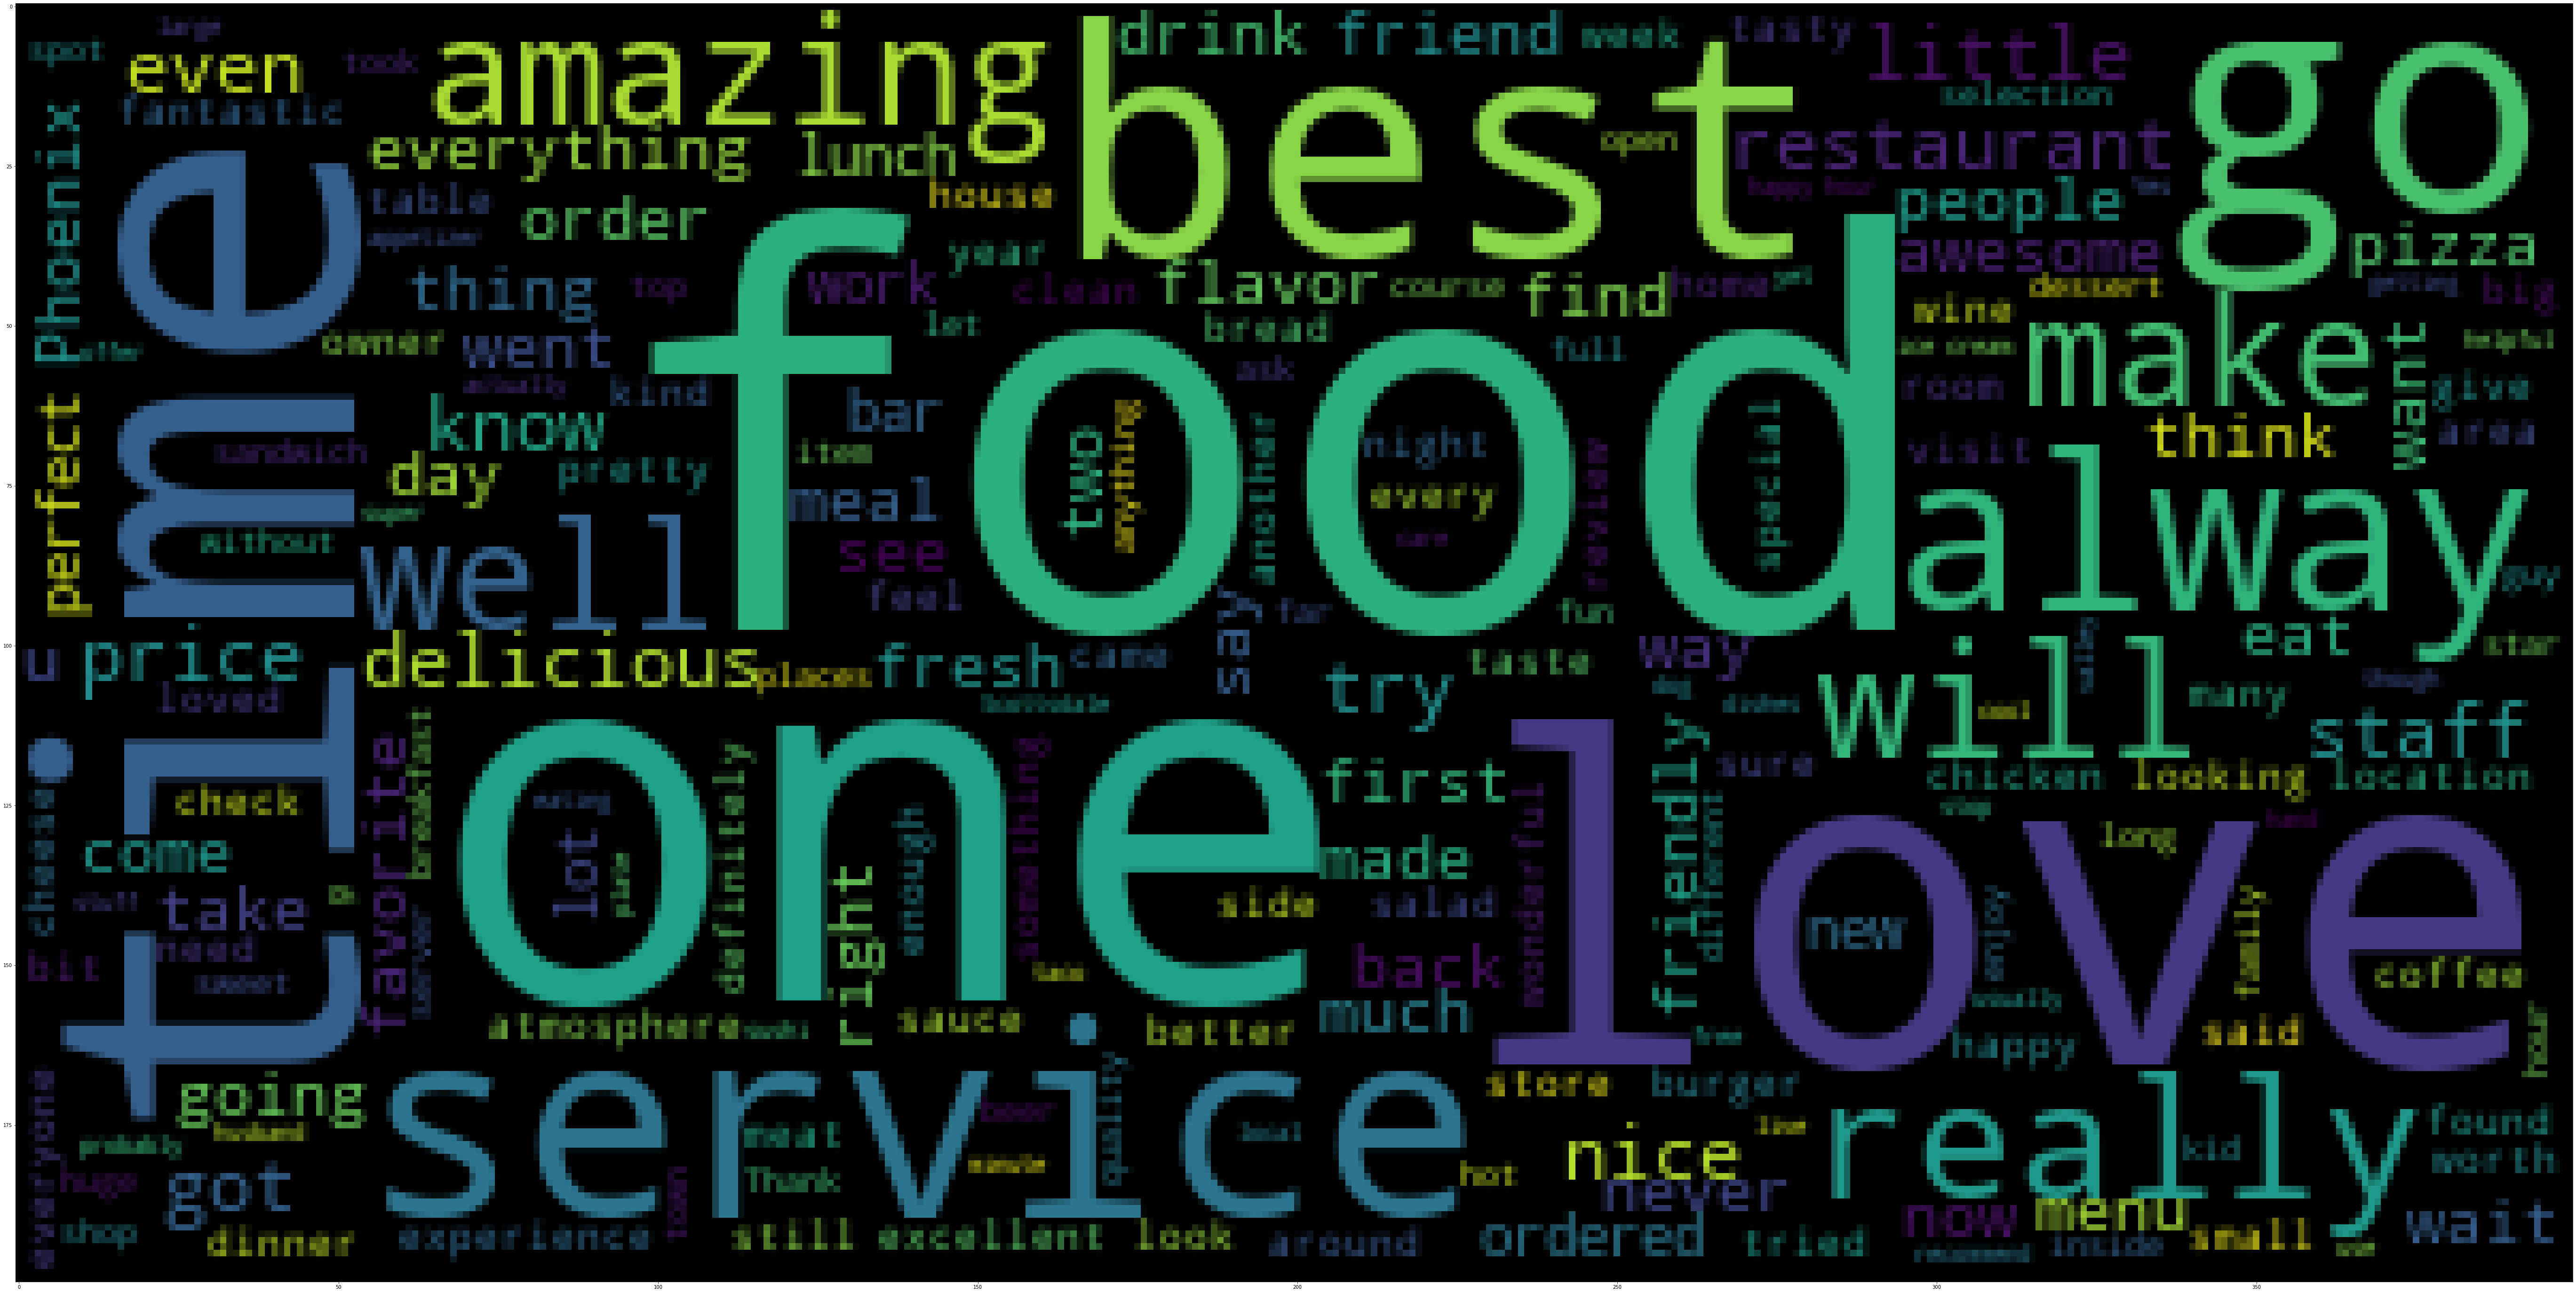

In [150]:
wc = WordCloud(stopwords = stop1).generate(' '.join(positive_ratings.tolist()))

%matplotlib inline
fig = plt.figure(figsize=(200,50))
plt.imshow(wc)

In [128]:
negative_ratings = df[df.stars == 1].text

In [129]:
negative_ratings.head(10)

23    U can go there n check the car out. If u wanna...
31    Disgusting!  Had a Groupon so my daughter and ...
35    I've eaten here many times, but none as bad as...
61    I have always been a fan of Burlington's deals...
64    Another night meeting friends here.  I have to...
65    Not busy at all but took nearly 45 min to get ...
71    Yikes, reading other reviews I realize my bad ...
79    This is my first year participating in Arizona...
84    really, I can't believe this place has receive...
89    I was really excited about this event, maybe m...
Name: text, dtype: object

In [130]:
' '.join(negative_ratings.tolist())

'U can go there n check the car out. If u wanna buy 1 there? That\'s wrong move! If u even want a car service from there? U made a biggest mistake of ur life!! I had 1 time asked my girlfriend to take my car there for an oil service, guess what? They ripped my girlfriend off by lying how bad my car is now. If without fixing the problem. Might bring some serious accident. Then she did what they said. 4 brand new tires, timing belt, 4 new brake pads. U know why\'s the worst? All of those above I had just changed 2 months before!!! What a trashy dealer is that? People, better off go somewhere! Disgusting!  Had a Groupon so my daughter and I tried it out.  Very outdated and gaudy 80\'s style interior made me feel like I was in an episode of Sopranos.  The food itself was pretty bad.  We ordered pretty simple dishes but they just had no flavor at all!  After trying it out I\'m positive all the good reviews on here are employees or owners creating them. I\'ve eaten here many times, but none 

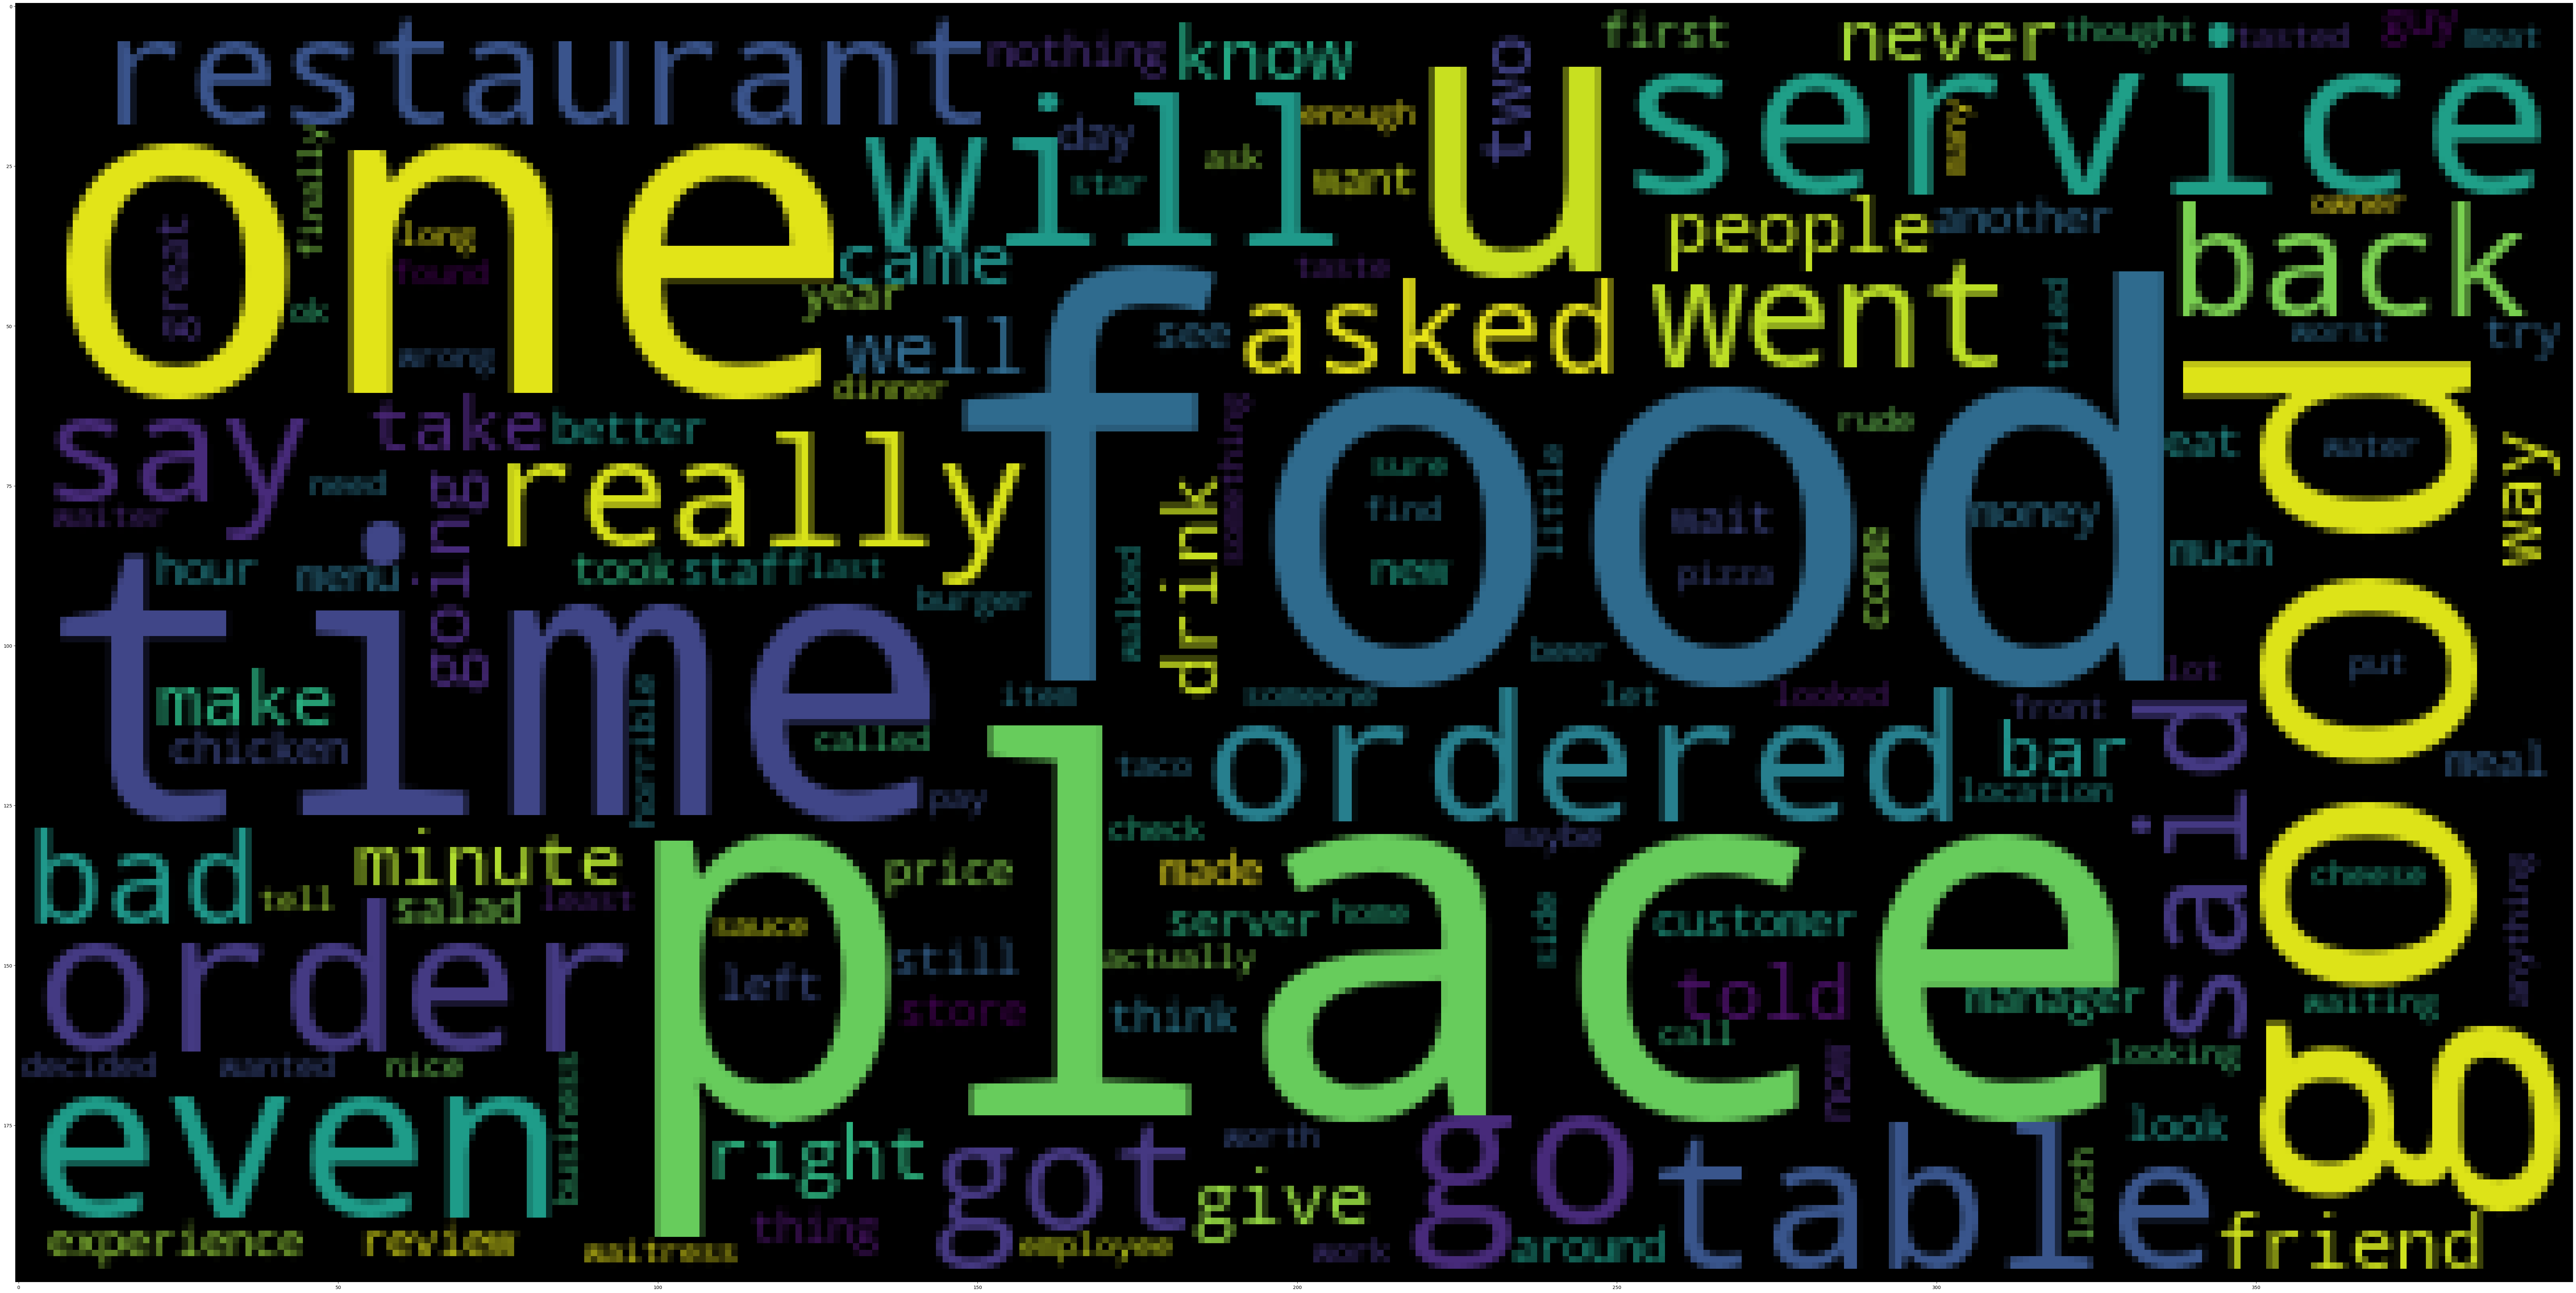

In [131]:
wc = WordCloud(stopwords = STOPWORDS).generate(' '.join(negative_ratings.tolist()))

%matplotlib inline
fig = plt.figure(figsize=(200,50))
plt.imshow(wc)

In [ ]:
print(args, sep = " ", end = "\n")     #\n  is Escape Sequence Character/Nweline character: it changes the line.

In [139]:
for i in range(1,11):
    print(i, end = " ")

1 2 3 4 5 6 7 8 9 10 